In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

In [2]:
def load_dataset(path, image_size=(100, 100)):
    faces = []
    labels = []
    
    label = 0
    
    for person in sorted(os.listdir(path)):
        person_path = os.path.join(path, person)
        
        if not os.path.isdir(person_path):
            continue
        
        for img_name in os.listdir(person_path):
            img_path = os.path.join(person_path, img_name)
            
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, image_size)
            
            faces.append(img)
            labels.append(label)
        
        label += 1
    
    return np.array(faces), np.array(labels)

dataset_path = "dataset"  # Update this path
X, y = load_dataset(dataset_path)

print("Dataset shape:", X.shape)

Dataset shape: (400, 100, 100)


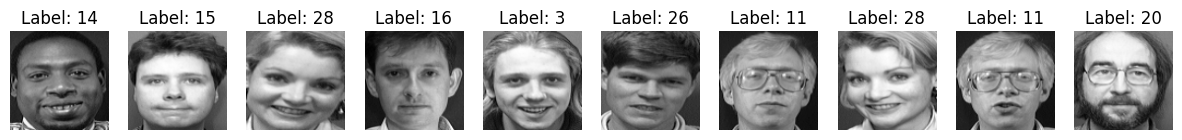

In [3]:
def show_random_faces(X, y, n=10):
    plt.figure(figsize=(15, 4))
    
    indices = random.sample(range(len(X)), n)
    
    for i, idx in enumerate(indices):
        plt.subplot(1, n, i + 1)
        plt.imshow(X[idx], cmap='gray')
        plt.title(f"Label: {y[idx]}")
        plt.axis('off')
    
    plt.show()

show_random_faces(X, y)

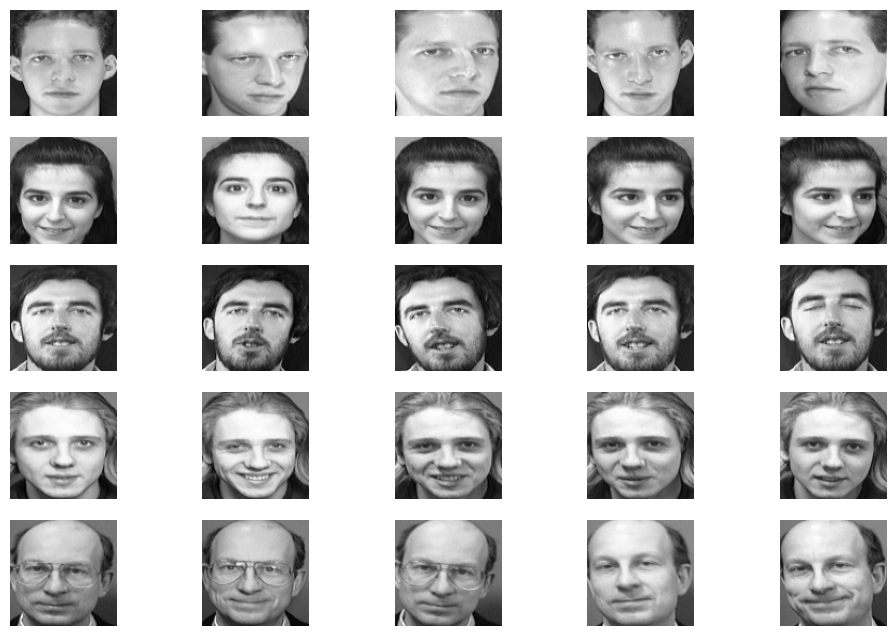

In [4]:
def show_faces_per_person(X, y, persons=5, images_per_person=5):
    unique_labels = np.unique(y)
    
    plt.figure(figsize=(12, 8))
    
    for i, label in enumerate(unique_labels[:persons]):
        idxs = np.where(y == label)[0][:images_per_person]
        
        for j, idx in enumerate(idxs):
            plt.subplot(persons, images_per_person, i * images_per_person + j + 1)
            plt.imshow(X[idx], cmap='gray')
            plt.axis('off')
            
            if j == 0:
                plt.ylabel(f"Person {label}")
    
    plt.show()

show_faces_per_person(X, y)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=32)

In [7]:
lbph = cv2.face.LBPHFaceRecognizer_create(radius=1, neighbors=8,grid_x=8,grid_y=8)
lbph.train(X_train, y_train)

In [8]:
lbph_preds = []

for img in X_test:
    label, confidence = lbph.predict(img)
    lbph_preds.append(label)

lbph_preds = np.array(lbph_preds)

In [9]:
print("LBPH Accuracy:", accuracy_score(y_test, lbph_preds))
print(classification_report(y_test, lbph_preds))

LBPH Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         2
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         2
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         2
           8       1.00      1.00      1.00         2
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         2
          11       1.00      1.00      1.00         2
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         2
          14       1.00      1.00      1.00         2
          15       1.00      1.00      1.00         2
          16       1.00      1.00      1.00         2
        

In [10]:
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

In [11]:
pca = PCA(n_components=100, whiten=True, random_state=27)

X_train_pca = pca.fit_transform(X_train_flat)
X_test_pca = pca.transform(X_test_flat)

In [12]:
clf = SVC(kernel='rbf', class_weight='balanced')
clf.fit(X_train_pca, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [13]:
eigen_preds = clf.predict(X_test_pca)

In [14]:
print("EigenFaces Accuracy:", accuracy_score(y_test, eigen_preds))
print(classification_report(y_test, eigen_preds))

EigenFaces Accuracy: 0.9625
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         2
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         2
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         2
           8       1.00      1.00      1.00         2
           9       1.00      1.00      1.00         2
          10       1.00      0.50      0.67         2
          11       1.00      1.00      1.00         2
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         2
          14       1.00      1.00      1.00         2
          15       1.00      1.00      1.00         2
          16       1.00      1.00      1.00         2

In [ ]:
pca_fisher = PCA(n_components=100, whiten=True, random_state=32)

X_train_pca_f = pca_fisher.fit_transform(X_train_flat)
X_test_pca_f = pca_fisher.transform(X_test_flat)

In [16]:
lda = LDA()

X_train_lda = lda.fit_transform(X_train_pca_f, y_train)
X_test_lda = lda.transform(X_test_pca_f)

In [17]:
clf_fisher = SVC(kernel='rbf', class_weight='balanced')
clf_fisher.fit(X_train_lda, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [18]:
fisher_preds = clf_fisher.predict(X_test_lda)

In [19]:
print("FisherFaces Accuracy:", accuracy_score(y_test, fisher_preds))
print(classification_report(y_test, fisher_preds))

FisherFaces Accuracy: 0.9875
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         2
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         2
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         2
           8       1.00      1.00      1.00         2
           9       1.00      1.00      1.00         2
          10       1.00      0.50      0.67         2
          11       1.00      1.00      1.00         2
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         2
          14       1.00      1.00      1.00         2
          15       1.00      1.00      1.00         2
          16       1.00      1.00      1.00         

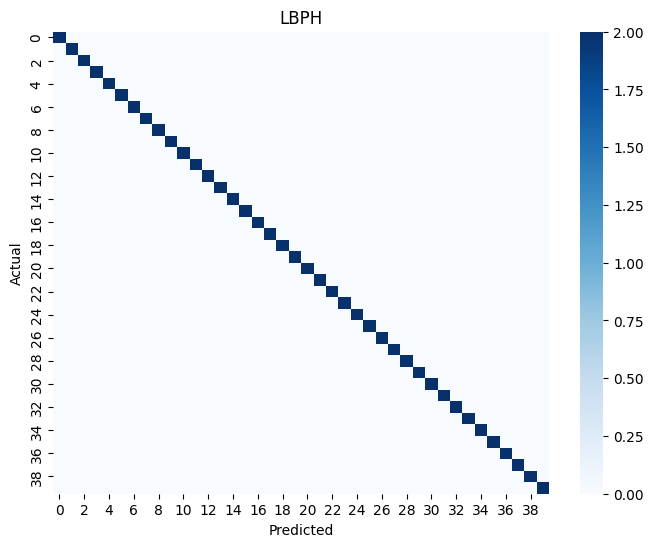

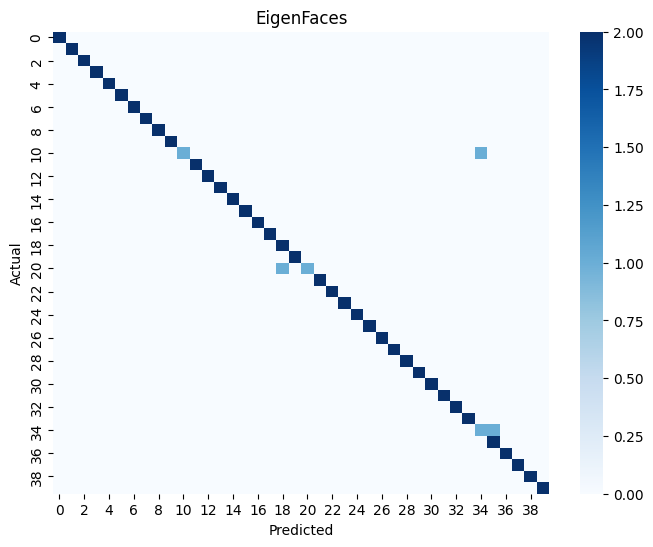

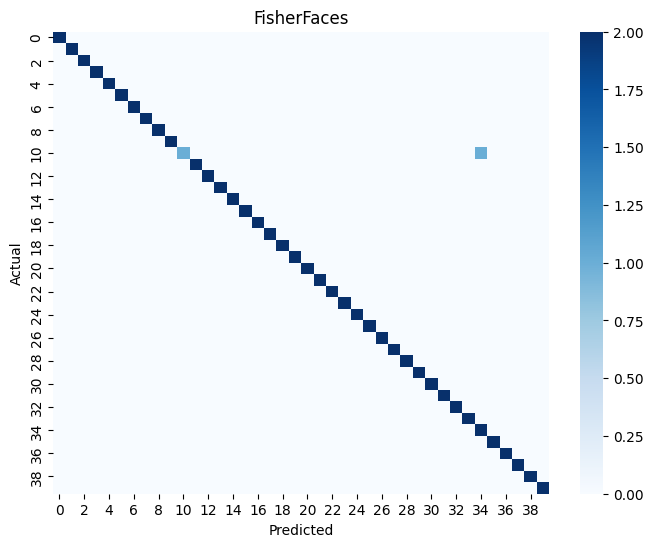

In [20]:
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_cm(y_test, lbph_preds, "LBPH")
plot_cm(y_test, eigen_preds, "EigenFaces")
plot_cm(y_test, fisher_preds, "FisherFaces")

In [21]:
print("Final Comparison")
print("------------------------")
print(f"LBPH        : {accuracy_score(y_test, lbph_preds):.4f}")
print(f"EigenFaces  : {accuracy_score(y_test, eigen_preds):.4f}")
print(f"FisherFaces : {accuracy_score(y_test, fisher_preds):.4f}")

Final Comparison
------------------------
LBPH        : 1.0000
EigenFaces  : 0.9625
FisherFaces : 0.9875


In [21]:
print("FisherFaces Accuracy:", accuracy_score(y_test, fisher_preds))
print("\nClassification Report:\n", classification_report(y_test, fisher_preds))

FisherFaces Accuracy: 0.9875

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         2
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         2
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         2
           8       1.00      1.00      1.00         2
           9       1.00      1.00      1.00         2
          10       1.00      0.50      0.67         2
          11       1.00      1.00      1.00         2
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         2
          14       1.00      1.00      1.00         2
          15       1.00      1.00      1.00         2
          16       1.00    

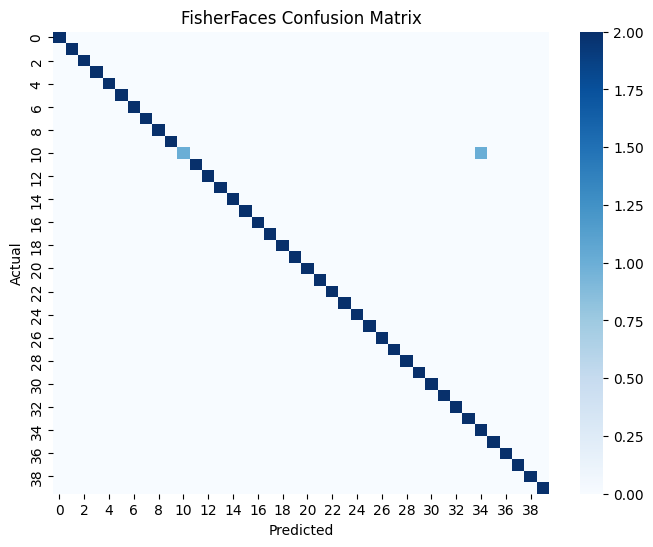

In [22]:
plot_cm(y_test, fisher_preds, "FisherFaces Confusion Matrix")

In [23]:
print("Final Comparison:")
print("---------------------------")
print(f"LBPH Accuracy       : {accuracy_score(y_test, lbph_preds):.4f}")
print(f"EigenFaces Accuracy : {accuracy_score(y_test, eigen_preds):.4f}")
print(f"FisherFaces Accuracy: {accuracy_score(y_test, fisher_preds):.4f}")

Final Comparison:
---------------------------
LBPH Accuracy       : 1.0000
EigenFaces Accuracy : 0.9625
FisherFaces Accuracy: 0.9875
